# Day 8 – Model Evaluation

## Objective

Learn model evaluation metrics and apply them to regression models.

---


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_csv("student_scores_1.csv")

df

,Name,Hours_Studied,Final_Score,Previous_Score,Attendance
0,STU_001,4.4,67.0,58.0,85.0
1,STU_002,9.6,100.0,97.0,96.0
2,STU_003,7.6,89.9,86.0,91.0
3,STU_004,6.4,74.8,69.0,83.0
4,STU_005,2.4,48.4,42.0,81.0
...,...,...,...,...,...
497,STU_498,1.7,53.8,NaN,77.0
498,STU_499,9.8,100.0,99.0,91.0
499,STU_500,9.9,100.0,94.0,93.0
500,STU_021,6.5,73.0,65.0,88.0


In [3]:
df["Attendance"] = df["Attendance"].fillna(df["Attendance"].mean())
df["Previous_Score"] = df["Previous_Score"].fillna(df["Previous_Score"].mean())
df["Hours_Studied"] = df["Hours_Studied"].fillna(df["Hours_Studied"].mean())
df["Final_Score"] = df["Final_Score"].fillna(df["Final_Score"].mean())

In [4]:
X = df[["Hours_Studied"]]
y = df["Final_Score"]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [6]:
model = LinearRegression()

model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [27]:
y_pred = model.predict(X_test)

print("Actual Scores")
print(y_test.values)

print()

print("Predicted Scores")
print(y_pred)

print(model.coef_)

print(model.intercept_)

Actual Scores
[ 76.9  83.5  73.2  52.2  95.   92.5  64.3  58.6  45.9  36.4  81.5  61.3
  82.7  60.2  85.5  95.7  53.8  86.1  47.1  38.4  59.6  60.7  57.6  60.3
  83.5  74.4  43.9  71.7  74.1  38.1  84.4  40.3  63.2  54.5  89.9  48.2
  93.6  87.1  73.2  58.7  38.2  81.4  56.   89.2  97.2  49.6  67.  100.
  70.6  60.9  41.4  86.3  51.7  97.7  65.1  95.5  44.   66.1  69.2  63.5
  74.6 100.   98.6  90.4  49.3  75.8  94.   60.2  81.9  90.7  58.6  49.4
  79.7  54.8  45.1 100.   83.5  95.4  72.2  55.7 100.   60.1  78.1  74.7
  70.4  53.9  53.2  60.8  95.3  93.8  62.9  74.4  55.8  84.6  55.1 100.
  77.5  85.3  57.1  51.7  65.1]

Predicted Scores
[64.04640927 89.594093   77.13180825 57.81526689 95.20212114 93.95589266
 64.6695235  57.19215266 48.46855333 44.72986791 83.98606487 63.42329503
 84.6091791  61.55395232 82.11672215 99.5639208  48.46855333 78.37803673
 54.07658147 44.72986791 59.68460961 54.69969571 57.81526689 65.91575198
 87.10163605 77.13180825 46.59921062 72.14689435 79.6242652  4

In [28]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error : {mae:.2f}")
print(f"Mean Squared Error  : {mse:.2f}")
print(f"R² Score            : {r2:.2f}")

Mean Absolute Error : 3.65
Mean Squared Error  : 21.68
R² Score            : 0.93


In [29]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison

,Actual,Predicted
0,76.9,64.046409
1,83.5,89.594093
2,73.2,77.131808
3,52.2,57.815267
4,95.0,95.202121
...,...,...
96,77.5,85.232293
97,85.3,85.232293
98,57.1,49.091668
99,51.7,54.699696


In [31]:
file_path = "predictions.csv"

if os.path.exists(file_path):
    comparison.to_csv(file_path, mode="a", header=False, index=False)
else:
    comparison.to_csv(file_path, index=False)

print("Data saved successfully!")

Data saved successfully!


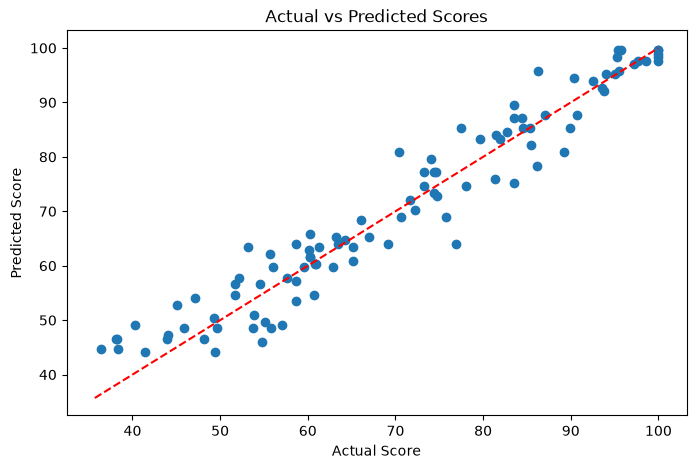

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred)

plt.plot(
    [y.min(), y.max()],
    [y.min(), y.max()],
    'r--'
)

plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")
plt.title("Actual vs Predicted Scores")

plt.show()